# Notebook 01: Synthetic Ellipse Case Study

**Obstacle-Aware Clustering for Geographic Data**

This notebook demonstrates why standard k-Means fails in the presence of geographic obstacles and how a loop-aware arc-length parameter corrects the problem. We work through a fully controlled synthetic example using an elliptical obstacle before applying the method to real-world data in later notebooks.

---

## 1. Setup

In [6]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import (
    EllipseBoundary, ObstacleKMeans,
    loop_aware_distance
)

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Defining the Obstacle

We define our obstacle as the level set of a 2D Gaussian function at threshold $c$:

$$A \cdot \exp\!\left(-\frac{(x-h)^2}{2\sigma_x^2} - \frac{(y-k)^2}{2\sigma_y^2}\right) = c$$

Setting $f(x,y) = c$ picks out a specific contour line of the Gaussian — the boundary of the obstacle. To find its shape, we take the log of both sides and rearrange:

$$\frac{(x-h)^2}{2\sigma_x^2} + \frac{(y-k)^2}{2\sigma_y^2} = -\ln(c/A)$$

Dividing through by $-\ln(c/A)$ puts this in the standard ellipse form $\frac{(x-h)^2}{a^2} + \frac{(y-k)^2}{b^2} = 1$, where the semi-axes are:

$$a = \sigma_x\sqrt{-2\ln(c/A)}, \qquad b = \sigma_y\sqrt{-2\ln(c/A)}$$

The shared factor $\sqrt{-2\ln(c/A)}$ is determined entirely by the ratio $c/A$. Using the identity $\cos^2(t) + \sin^2(t) = 1$, we can write the ellipse parametrically:

$$x(t) = \sigma_x \sqrt{-2\ln(c/A)}\,\cos(t) + h, \qquad y(t) = \sigma_y \sqrt{-2\ln(c/A)}\,\sin(t) + k$$

for $t \in [0, 2\pi]$. This parametric form gives us a single variable $t$ that tracks position along the boundary, which we need for computing arc lengths.

Semi-axis a (horizontal): 9.10
Semi-axis b (vertical):   1.82
Total arc length: 38.26


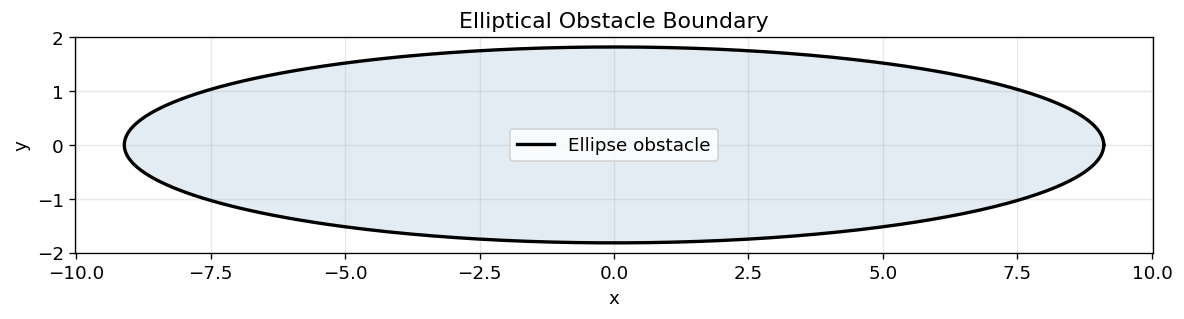

In [7]:
# Define the ellipse boundary
boundary = EllipseBoundary(
    sigma_x=3.0, sigma_y=0.6, # wide ellipse; 5:1 ratio
    h=0.0, k=0.0,             # centered at the origin
    c=0.01, A=1.0             # c/A = 0.01; sqrt_term ~ 3.03, semi-axes a~9.1, b~1.8
)

# Key measurements
L = boundary.total_arc_length()
a = boundary.sigma_x * boundary.sqrt_term  # horizontal semi-axis
b = boundary.sigma_y * boundary.sqrt_term  # vertical semi-axis
print(f'Semi-axis a (horizontal): {a:.2f}')
print(f'Semi-axis b (vertical):   {b:.2f}')
print(f'Total arc length: {L:.2f}')

# Plot the ellipse
boundary_pts = boundary.sample_boundary(500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k-', linewidth=2, label='Ellipse obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.15, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Elliptical Obstacle Boundary')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Generating Synthetic Data

We generate three clusters of 5 points each, simulating locations around a lake-like obstacle:

- **North-east shore**: Points above the ellipse, spread along the right half
- **South-east shore**: Points below the ellipse, in a similar x-range
- **West shore**: Points around the left tip of the ellipse

All points are placed outside the ellipse. The north-east and south-east clusters overlap in their x-range but sit on opposite sides of the obstacle. Near the right end of the ellipse where it narrows, some of these points are close in Euclidean distance despite being separated by the obstacle.

In [8]:
def generate_synthetic_data(seed=67):
    """Generate synthetic data around an elliptical obstacle.
    
    Three clusters simulate locations around a lake.
    North-east and south-east clusters share x-range but are
    separated by the obstacle.
    """
    np.random.seed(seed)
    
    # North-east shore: above the ellipse, right half
    north = np.array([
        [1.0, 2.5],
        [3.0, 2.3],
        [5.0, 2.1],
        [6.5, 1.8],
        [7.5, 1.4],
    ]) + np.random.normal(0, 0.12, (5, 2))
    
    # South-east shore: below the ellipse, same x-range
    south = np.array([
        [1.0, -2.5],
        [3.0, -2.3],
        [5.0, -2.1],
        [6.5, -1.8],
        [7.5, -1.4],
    ]) + np.random.normal(0, 0.12, (5, 2))
    
    # West shore: around the left tip
    west = np.array([
        [-10.0, 1.0],
        [-10.5, 0.0],
        [-10.0, -1.0],
        [-9.5, 1.5],
        [-9.5, -1.5],
    ]) + np.random.normal(0, 0.12, (5, 2))
    
    raw_data = np.vstack([north, south, west])
    true_labels = np.array([0]*5 + [1]*5 + [2]*5)
    
    return raw_data, true_labels


# Generate data
raw_data, true_labels = generate_synthetic_data()
print(f'Generated {len(raw_data)} data points across 3 clusters')
print(f'Shape: {raw_data.shape}')

Generated 15 data points across 3 clusters
Shape: (15, 2)


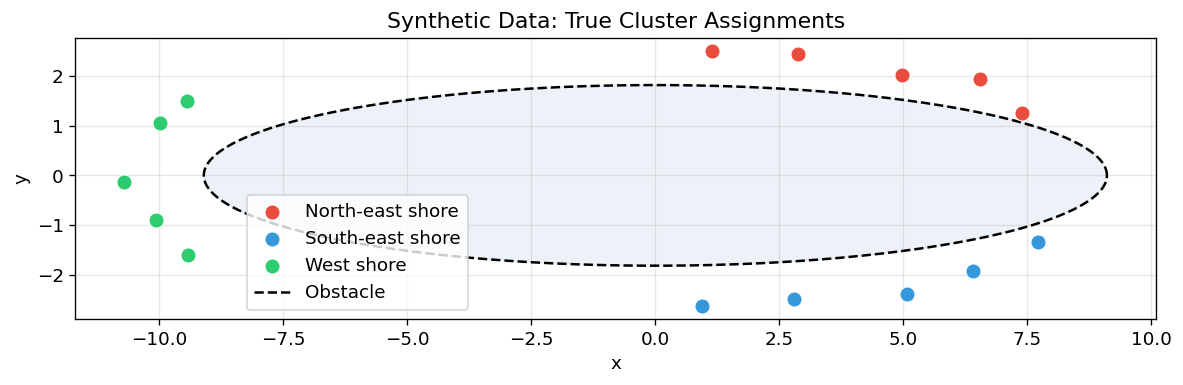

In [4]:
# Visualize raw data with true cluster labels
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels_text = ['North-east shore', 'South-east shore', 'West shore']

for i in range(3):
    mask = true_labels == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=colors[i],
              s=80, edgecolors='white', linewidth=0.5, label=labels_text[i], zorder=3)

# Draw the ellipse
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Synthetic Data: True Cluster Assignments')
ax.legend(loc='lower left', bbox_to_anchor=(0.15, 0))
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Failure of Standard k-Means

Standard k-Means uses Euclidean distance in $(x, y)$ to assign points to clusters. It treats the space as unobstructed — the ellipse might as well not exist. Near the right end of the ellipse where the boundary narrows, points on opposite sides can be closer in Euclidean distance than points on the same side further along the shore.

In [9]:
# Run standard k-Means on (x, y)
kmeans_standard = KMeans(n_clusters=3, random_state=2, n_init=10)
labels_standard = kmeans_standard.fit_predict(raw_data)
print(f'Standard k-Means converged in {kmeans_standard.n_iter_} iterations')

# Check cluster composition
print('Standard k-Means cluster composition:')
for i in range(3):
    members = np.where(labels_standard == i)[0]
    comp = [np.sum(true_labels[members] == j) for j in range(3)]
    print(f'  Cluster {i+1}: north-east={comp[0]}, south-east={comp[1]}, west={comp[2]}')

# Identify misassigned points
print('\nMisassigned points:')
for idx in range(len(raw_data)):
    true_c = true_labels[idx]
    std_c = labels_standard[idx]
    members_of_std = np.where(labels_standard == std_c)[0]
    dominant = np.argmax([np.sum(true_labels[members_of_std] == j) for j in range(3)])
    if true_c != dominant:
        shore = ['north-east', 'south-east', 'west'][true_c]
        print(f'  Point {idx} ({shore} shore at ({raw_data[idx,0]:.1f}, {raw_data[idx,1]:.1f}))'
              f' was grouped with the wrong cluster')

Standard k-Means converged in 2 iterations
Standard k-Means cluster composition:
  Cluster 1: north-east=0, south-east=4, west=0
  Cluster 2: north-east=0, south-east=0, west=5
  Cluster 3: north-east=5, south-east=1, west=0

Misassigned points:
  Point 9 (south-east shore at (7.7, -1.3)) was grouped with the wrong cluster


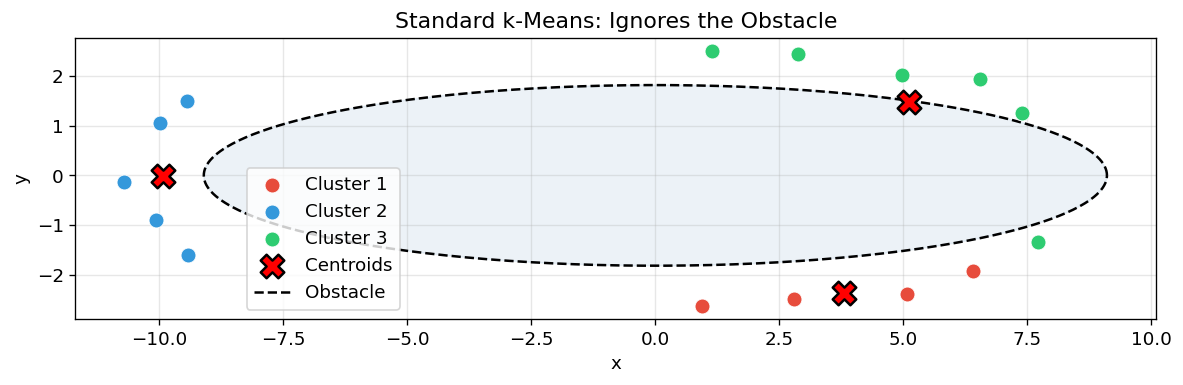

In [10]:
# Plot standard k-Means result
fig, ax = plt.subplots(figsize=(10, 6))

cmap = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    mask = labels_standard == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=cmap[i],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)

ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4, label='Centroids')

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-Means: Ignores the Obstacle')
ax.legend(loc='lower left', bbox_to_anchor=(0.15,0))
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. The Arc-Length Parameter $s$

To encode obstacle awareness, we assign each data point a value $s \in [0, 1]$ that represents its position along the obstacle boundary. The process works as follows:

First, recall that the ellipse is parameterized by a variable $t \in [0, 2\pi]$, where each value of $t$ corresponds to a specific point on the boundary. The starting point $t = 0$ is at the rightmost tip of the ellipse, and $t$ increases counter-clockwise around the curve.

For each data point, we:

1. **Project** it onto the nearest point on the ellipse boundary, finding the corresponding parameter value $t^*$
2. **Compute the arc length** along the boundary from the starting point ($t=0$) to $t^*$
3. **Normalize** by dividing by the total perimeter $L$, giving $s = \text{arc length to } t^* \,/\, L$

The result is that every data point gets an $s$ value between 0 and 1, where $s = 0$ and $s = 1$ both correspond to the rightmost tip. Points near each other along the shoreline have similar $s$ values, while points on opposite sides of the ellipse have very different $s$ values — even if they are close in Euclidean distance.

Because the boundary is a closed loop, we use a **loop-aware distance**:

$$d_s(s_1, s_2) = \min\big(|s_1 - s_2|,\; 1 - |s_1 - s_2|\big)$$

This ensures that points near the seam (e.g., $s = 0.02$ and $s = 0.98$) are correctly recognized as close.

In [11]:
# Project each data point onto the ellipse and compute s
t_values = []
s_values = []

for x_p, y_p in raw_data:
    t_closest, s_closest = boundary.project_point(x_p, y_p)
    t_values.append(t_closest)
    s_values.append(s_closest)

t_values = np.array(t_values)
s_values = np.array(s_values)

# Display s values grouped by shore
shore_names = ['North-east']*5 + ['South-east']*5 + ['West']*5
print('Arc-length values (s) for each point:')
for i, (x, y, s, shore) in enumerate(zip(raw_data[:, 0], raw_data[:, 1], s_values, shore_names)):
    print(f'  {shore:10s}: ({x:6.2f}, {y:6.2f})  ->  s = {s:.4f}')

print('\nNotice: north-east points have small s values, south-east points have')
print('large s values. They are far apart in arc-length even when close in (x,y).')

Arc-length values (s) for each point:
  North-east: (  1.14,   2.52)  ->  s = 0.2208
  North-east: (  2.87,   2.45)  ->  s = 0.1763
  North-east: (  4.98,   2.03)  ->  s = 0.1212
  North-east: (  6.54,   1.95)  ->  s = 0.0816
  North-east: (  7.40,   1.27)  ->  s = 0.0565
  South-east: (  0.94,  -2.63)  ->  s = 0.7741
  South-east: (  2.80,  -2.50)  ->  s = 0.8221
  South-east: (  5.08,  -2.39)  ->  s = 0.8802
  South-east: (  6.41,  -1.93)  ->  s = 0.9152
  South-east: (  7.71,  -1.35)  ->  s = 0.9506
  West      : ( -9.99,   1.06)  ->  s = 0.4919
  West      : (-10.70,  -0.14)  ->  s = 0.5007
  West      : (-10.07,  -0.89)  ->  s = 0.5064
  West      : ( -9.44,   1.51)  ->  s = 0.4831
  West      : ( -9.43,  -1.60)  ->  s = 0.5177

Notice: north-east points have small s values, south-east points have
large s values. They are far apart in arc-length even when close in (x,y).


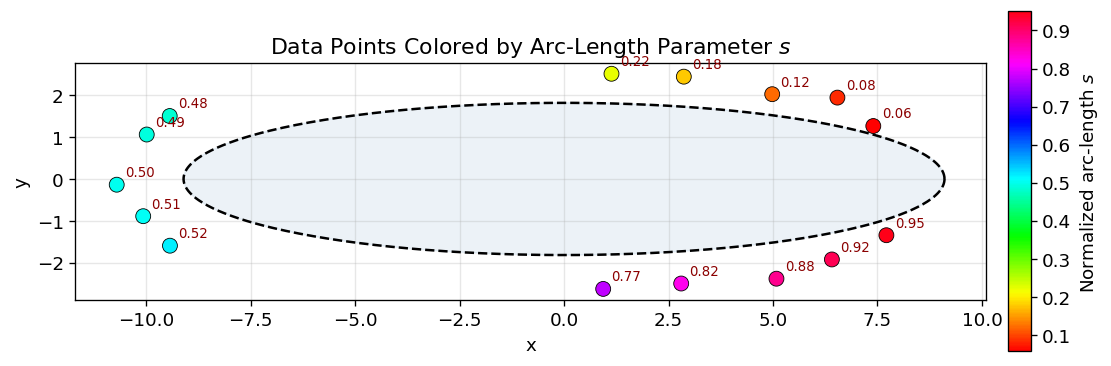

In [12]:
# Visualize points colored by their s value
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(raw_data[:, 0], raw_data[:, 1], c=s_values, cmap='hsv',
                     s=80, edgecolors='black', linewidth=0.5, zorder=3)
plt.colorbar(scatter, ax=ax, label='Normalized arc-length $s$', shrink=0.5, aspect=15, pad=0.02)

for i, (x, y, s) in enumerate(zip(raw_data[:, 0], raw_data[:, 1], s_values)):
    ax.annotate(f'{s:.2f}', (x, y), textcoords='offset points',
               xytext=(5, 5), fontsize=8, color='darkred')

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data Points Colored by Arc-Length Parameter $s$')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Demonstrate loop-aware distance
print('Loop-aware distance examples:')
print(f'  d(0.05, 0.95) = {loop_aware_distance(0.05, 0.95):.2f}  (close — wraps around the seam)')
print(f'  d(0.05, 0.50) = {loop_aware_distance(0.05, 0.50):.2f}  (far — opposite sides)')
print(f'  d(0.30, 0.70) = {loop_aware_distance(0.30, 0.70):.2f}  (moderately far)')
print(f'  d(0.10, 0.20) = {loop_aware_distance(0.10, 0.20):.2f}  (close — same region)')

Loop-aware distance examples:
  d(0.05, 0.95) = 0.10  (close — wraps around the seam)
  d(0.05, 0.50) = 0.45  (far — opposite sides)
  d(0.30, 0.70) = 0.40  (moderately far)
  d(0.10, 0.20) = 0.10  (close — same region)


## 6. Feature Engineering

We construct the feature vector for clustering by combining the scaled $(x, y)$ coordinates with the arc-length parameter $s$:

$$\mathbf{x}_i = (x_i^{\text{scaled}},\; y_i^{\text{scaled}},\; s_i)$$

The $(x, y)$ coordinates are normalized to $[0, 1]$ using Min-Max scaling so they are on a comparable scale with $s$, which is already in $[0, 1]$ by construction.

In [14]:
# Normalize x, y to [0, 1]
scaler = MinMaxScaler()
xy_scaled = scaler.fit_transform(raw_data)

# Combine into feature matrix: [x_scaled, y_scaled, s]
X = np.column_stack([xy_scaled, s_values])

print(f'Feature matrix shape: {X.shape}')
print(f'Features: x_scaled, y_scaled, s')
print(f'\nFirst 5 rows (north-east shore):')
print(np.array2string(X[:5], precision=4, suppress_small=True))
print(f'\nRows 5-9 (south-east shore):')
print(np.array2string(X[5:10], precision=4, suppress_small=True))

Feature matrix shape: (15, 3)
Features: x_scaled, y_scaled, s

First 5 rows (north-east shore):
[[0.6428 1.     0.2208]
 [0.7368 0.9865 0.1763]
 [0.8516 0.905  0.1212]
 [0.9364 0.8891 0.0816]
 [0.983  0.7571 0.0565]]

Rows 5-9 (south-east shore):
[[0.632  0.     0.7741]
 [0.7334 0.0251 0.8221]
 [0.8572 0.0475 0.8802]
 [0.9292 0.1369 0.9152]
 [1.     0.2495 0.9506]]


## 7. Obstacle-Aware k-Means

Our modified k-Means uses a weighted composite distance:

$$d^2(\mathbf{x}_i, \mathbf{c}_j) = \alpha^2 \|(x_i, y_i) - (c_{jx}, c_{jy})\|^2 + \beta^2\, d_s(s_i, s_{c_j})^2$$

The weight $\alpha$ controls how much geographic proximity matters, and $\beta$ controls how much the arc-length position matters. For this toy problem, we set both to 1.0, giving equal influence to geography and arc-length. The goal here is simply to show that including $s$ fixes the misassignment — tuning the balance between $\alpha$ and $\beta$ becomes important in the real-world application (Notebook 03), where we also introduce a third weight $\gamma$ for data attributes.

The centroid update for $s$ uses **boundary-aware projection** rather than naive averaging of $s$ values — this is necessary because $s$ lives on a circular domain where simple averaging fails.

In [15]:
# Run obstacle-aware k-Means (spatial only)
model = ObstacleKMeans(
    k=3,
    boundary=boundary,
    alpha=1.0,          # geographic weight
    beta=1.0,           # arc-length weight (equal to alpha for this demo)
    gamma=0.0,          # no attributes in this demo
    random_state=42,
    n_attr=0
)
model.fit(X, t_data=t_values)

labels_obstacle = model.labels_

print(f'Obstacle-aware k-Means converged in {model.n_iter_} iterations')

print('\nObstacle-aware cluster composition:')
for i in range(3):
    members = np.where(labels_obstacle == i)[0]
    comp = [np.sum(true_labels[members] == j) for j in range(3)]
    print(f'  Cluster {i+1}: north-east={comp[0]}, south-east={comp[1]}, west={comp[2]}')

Obstacle-aware k-Means converged in 2 iterations

Obstacle-aware cluster composition:
  Cluster 1: north-east=0, south-east=5, west=0
  Cluster 2: north-east=0, south-east=0, west=5
  Cluster 3: north-east=5, south-east=0, west=0


## 8. Comparison: Standard vs. Obstacle-Aware

Standard k-Means uses only $(x, y)$ and ignores the obstacle. The obstacle-aware version adds the arc-length parameter $s$, which encodes each point's position along the boundary.

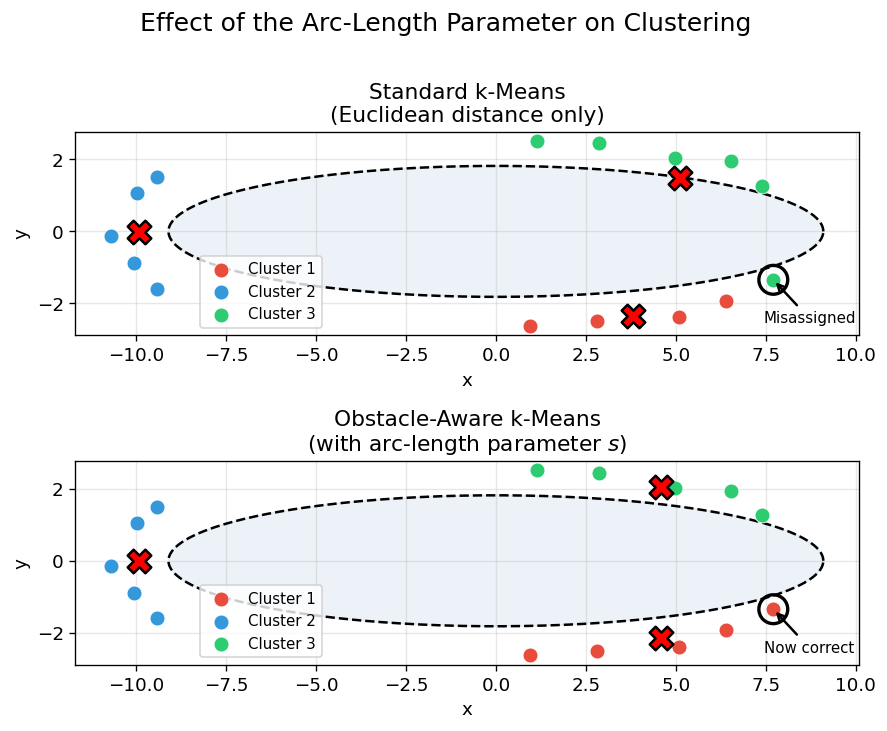

In [16]:
# Stacked comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
fig.subplots_adjust(hspace=0.4)

cmap = ['#e74c3c', '#3498db', '#2ecc71']

# --- Standard k-Means ---
ax = axes[0]
for i in range(3):
    mask = labels_standard == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=cmap[i],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)
ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4)
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')
# Circle the misassigned point
misassigned_pt = raw_data[9]  # south-east point grouped with north-east
ax.scatter(misassigned_pt[0], misassigned_pt[1], s=300, facecolors='none',
           edgecolors='black', linewidth=2, zorder=5)
ax.annotate('Misassigned', xy=(misassigned_pt[0], misassigned_pt[1]),
            xytext=(misassigned_pt[0]+1, misassigned_pt[1]-1.2),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-Means\n(Euclidean distance only)', fontsize=13)
ax.legend(loc='lower left', bbox_to_anchor=(0.15,0), fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Obstacle-Aware k-Means ---
ax = axes[1]
for i in range(3):
    mask = labels_obstacle == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=cmap[i],
              s=80, edgecolors='white', linewidth=0.5, label=f'Cluster {i+1}', zorder=3)
for i in range(3):
    mask = labels_obstacle == i
    cx, cy = np.mean(raw_data[mask, 0]), np.mean(raw_data[mask, 1])
    ax.scatter(cx, cy, c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=4)
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')
# Circle the previously misassigned point — now correctly assigned
corrected_pt = raw_data[9]
ax.scatter(corrected_pt[0], corrected_pt[1], s=300, facecolors='none',
           edgecolors='black', linewidth=2, zorder=5)
ax.annotate('Now correct', xy=(corrected_pt[0], corrected_pt[1]),
            xytext=(corrected_pt[0]+1, corrected_pt[1]-1.2),
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Obstacle-Aware k-Means\n(with arc-length parameter $s$)', fontsize=13)
ax.legend(loc='lower left', bbox_to_anchor=(0.15,0), fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Effect of the Arc-Length Parameter on Clustering', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 9. Discussion

This synthetic case study demonstrates the core idea:

1. **Standard k-Means fails** when points on opposite sides of an obstacle are close in Euclidean distance. A south-east shore point was incorrectly grouped with north-east shore points because the straight-line distance across the obstacle was shorter than the distance to its true cluster mates along the shore.

2. **The arc-length parameter** $s$ encodes each point's position along the obstacle boundary. Its loop-aware distance correctly measures separation *around* the obstacle rather than *through* it.

3. **The modified k-Means** combines Euclidean geography $(x, y)$ with the loop-aware arc-length $s$ in a weighted distance. Centroid updates for $s$ use boundary-aware projection rather than naive averaging.

4. **The approach is general**: it does not depend on the obstacle being an ellipse. Any smooth closed curve that admits a parameterization will work — including cubic splines fitted to real-world boundaries like lakes.

### What's Next

This notebook focused purely on spatial clustering to clearly isolate the effect of the arc-length parameter. In the real-world application (Notebook 03), we extend the distance metric to include **attribute features** such as fire size and cause category, creating a dual-domain clustering approach:

$$d^2 = \alpha^2 \cdot \text{(geography)} + \beta^2 \cdot \text{(arc-length)} + \gamma^2 \cdot \text{(attributes)}$$

This allows the algorithm to find clusters that are both spatially coherent around the obstacle *and* meaningfully different in their attribute profiles — a capability that standard spatial clustering methods lack.